# ML Perairan — Anggota 3 (Morowali/Bahodopi)
Alur: load ground truth 2024 & 2025 → ekstrak band dari `feature_stack` → split 70:30 (`random_state=42`, konsisten sama Anggota 2) → train Random Forest (100 trees) per tahun → evaluasi APRF → klasifikasi penuh 2024 & 2025 → analisis perubahan (gain/loss) → export ke folder tim.

**Output akhir:**
- `02_Modeling/best_model_rf_air_2024.pkl`, `best_model_rf_air_2025.pkl`
- `03_Evaluasi/metrik_aprf_air.txt`
- `03_Hasil_Klasifikasi/klasifikasi_air_2024.tif`, `klasifikasi_air_2025.tif`, `change_map_air.tif`


In [56]:
import pandas as pd
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              precision_recall_curve)
import joblib
import os

RANDOM_STATE = 42
FEATURE_COLS = ['B2','B3','B4','B8','B11','B12','NDVI','NDWI','NDBI','BSI','NDTI']

PATHS = {
    2024: {
        "gt_csv": "data/gt_air_2024_manual_v2.csv",
        "feature_stack": "data/feature_stack_2024.tif",
    },
    2025: {
        "gt_csv": "data/gt_air_2025_manual_v2.csv",
        "feature_stack": "data/feature_stack_2025.tif",
    },
}

os.makedirs("01_Ground_Truth", exist_ok=True)
os.makedirs("02_Modeling", exist_ok=True)
os.makedirs("03_Evaluasi", exist_ok=True)
os.makedirs("03_Hasil_Klasifikasi", exist_ok=True)
os.makedirs("04_GeoJSON_WebGIS", exist_ok=True)

print("✅ Setup folder selesai.")

✅ Setup folder selesai.


## 1. Cek isi ground truth
Kolom dari export GEE biasanya: `class`, `year`, `longitude`, `latitude`, `kategori`.
Kalau nama kolomnya beda, sesuaikan mapping di cell berikutnya.

=== gt 2024 ===
class
1    200
0    200
Name: count, dtype: int64

=== gt 2025 ===
class
1    200
0    200
Name: count, dtype: int64


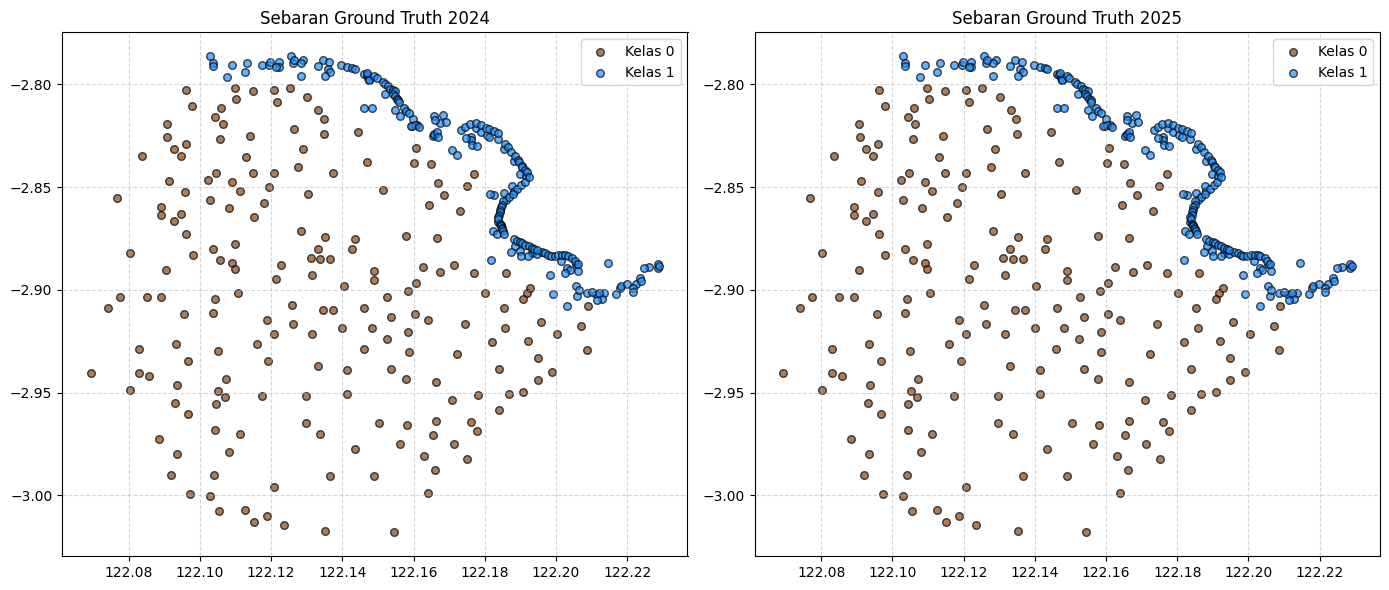

In [57]:
gt_2024_raw = pd.read_csv(PATHS[2024]["gt_csv"], sep=";")
gt_2025_raw = pd.read_csv(PATHS[2025]["gt_csv"], sep=";")

print("=== gt 2024 ===")
print(gt_2024_raw["class"].value_counts())
print("\n=== gt 2025 ===")
print(gt_2025_raw["class"].value_counts())

# Visualisasi Sebaran
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = {0: '#8B4513', 1: '#1E90FF'}

for cls, color in colors.items():
    subset = gt_2024_raw[gt_2024_raw['class'] == cls]
    axes[0].scatter(subset['longitude'], subset['latitude'], c=color, label=f"Kelas {cls}", alpha=0.7, edgecolors='k', s=30)
axes[0].set_title("Sebaran Ground Truth 2024")
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.5)

for cls, color in colors.items():
    subset = gt_2025_raw[gt_2025_raw['class'] == cls]
    axes[1].scatter(subset['longitude'], subset['latitude'], c=color, label=f"Kelas {cls}", alpha=0.7, edgecolors='k', s=30)
axes[1].set_title("Sebaran Ground Truth 2025")
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 2. Ekstraksi nilai band dari feature_stack
Ambil nilai 11 band (band mentah + indeks) di tiap titik koordinat ground truth, untuk tahun yang sesuai.

In [58]:
def ekstrak_band(feature_stack_path, gt_df, lon_col="longitude", lat_col="latitude"):
    with rasterio.open(feature_stack_path) as src:
        band_names = src.descriptions
        coords = list(zip(gt_df[lon_col], gt_df[lat_col]))
        values = np.array(list(src.sample(coords)))
    df_bands = pd.DataFrame(values, columns=band_names)
    return pd.concat([gt_df.reset_index(drop=True), df_bands], axis=1)

gt_2024 = ekstrak_band(PATHS[2024]["feature_stack"], gt_2024_raw).dropna(subset=FEATURE_COLS)
gt_2025 = ekstrak_band(PATHS[2025]["feature_stack"], gt_2025_raw).dropna(subset=FEATURE_COLS)

gt_2024.to_csv("01_Ground_Truth/gt_air_2024_with_bands.csv", index=False)
gt_2025.to_csv("01_Ground_Truth/gt_air_2025_with_bands.csv", index=False)
print(f"Ekstraksi selesai. 2024: {len(gt_2024)} titik, 2025: {len(gt_2025)} titik.")

Ekstraksi selesai. 2024: 375 titik, 2025: 398 titik.


## 3. Split 70:30 + training Random Forest (100 trees)

In [59]:
# 1. Gabungkan data 2024 dan 2025
gt_combined = pd.concat([gt_2024, gt_2025], ignore_index=True)

X = gt_combined[FEATURE_COLS]
y = gt_combined["class"]

# 2. Split 70:30 dari data gabungan
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

# 3. Train 1 model Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)

print(f"Data training gabungan: {len(X_train)} | Data testing gabungan: {len(X_test)}")

# Simpan 1 model aja
joblib.dump(rf_model, "02_Modeling/best_model_rf_air_combined.pkl")
print("Model tersimpan di 02_Modeling/best_model_rf_air_combined.pkl")

Data training gabungan: 541 | Data testing gabungan: 232
Model tersimpan di 02_Modeling/best_model_rf_air_combined.pkl


## 4. Evaluasi APRF (Accuracy, Precision, Recall, F1)

In [60]:
def evaluasi_aprf(rf, X_test, y_test, tahun):
    y_pred = rf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=["Darat (0)", "Air/Keruh (1)"])

    print(f"\n===== Metrik {tahun} =====")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print("Confusion Matrix:\n", cm)
    print(report)

    importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
    print("Feature importance:\n", importances)

    return {
        "tahun": tahun, "accuracy": acc, "precision": prec,
        "recall": rec, "f1": f1, "confusion_matrix": cm.tolist(),
        "report": report, "importances": importances
    }

metrik_gabungan = evaluasi_aprf(rf_model, X_test, y_test, "Gabungan 2024+2025")


===== Metrik Gabungan 2024+2025 =====
Accuracy  : 0.7888
Precision : 0.7734
Recall    : 0.8319
F1-score  : 0.8016
Confusion Matrix:
 [[84 29]
 [20 99]]
               precision    recall  f1-score   support

    Darat (0)       0.81      0.74      0.77       113
Air/Keruh (1)       0.77      0.83      0.80       119

     accuracy                           0.79       232
    macro avg       0.79      0.79      0.79       232
 weighted avg       0.79      0.79      0.79       232

Feature importance:
 NDWI    0.157586
NDVI    0.115109
NDTI    0.111506
NDBI    0.104499
B8      0.099620
BSI     0.085110
B11     0.078513
B12     0.077487
B4      0.059667
B2      0.055864
B3      0.055039
dtype: float64


In [61]:
def threshold_tuning(rf, X_test, y_test):
    y_prob = rf.predict_proba(X_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx]

    print(f"Threshold Optimal: {best_thresh:.4f} (F1 naik dari {f1_score(y_test, rf.predict(X_test)):.4f} -> {f1_scores[best_idx]:.4f})")
    return best_thresh

# Jalankan tuning untuk 1 model gabungan
best_thresh = threshold_tuning(rf_model, X_test, y_test)

Threshold Optimal: 0.4600 (F1 naik dari 0.8016 -> 0.8078)


In [62]:
# simpan metrik APRF ke file teks
with open("03_Evaluasi/metrik_aprf_air.txt", "w") as f:
    f.write(f"===== Metrik Objek Perairan - Model {metrik_gabungan['tahun']} =====\n")
    f.write(f"Accuracy  : {metrik_gabungan['accuracy']:.4f}\n")
    f.write(f"Precision : {metrik_gabungan['precision']:.4f}\n")
    f.write(f"Recall    : {metrik_gabungan['recall']:.4f}\n")
    f.write(f"F1-score  : {metrik_gabungan['f1']:.4f}\n")
    f.write(f"Confusion Matrix: {metrik_gabungan['confusion_matrix']}\n")
    f.write(metrik_gabungan['report'])
    f.write(f"\n\nCatatan: model dilatih dari data gabungan ground truth 2024+2025, ")
    f.write(f"diterapkan ke kedua tahun untuk klasifikasi. Threshold optimal (setelah tuning): {best_thresh:.4f}\n")

print("Metrik tersimpan di 03_Evaluasi/metrik_aprf_air.txt")

Metrik tersimpan di 03_Evaluasi/metrik_aprf_air.txt


## 5. Klasifikasi seluruh wilayah (2024 & 2025)
Terapkan masing-masing model ke seluruh `feature_stack`, hasilnya raster biner (1=air/keruh, 0=darat).

In [63]:
def klasifikasi_raster_tuned(feature_stack_path, model, output_path, threshold=0.5):
    with rasterio.open(feature_stack_path) as src:
        profile = src.profile
        bands = src.read()
        band_names = src.descriptions

    idx_order = [band_names.index(b) for b in FEATURE_COLS]
    bands_ordered = bands[idx_order]
    n_bands, height, width = bands_ordered.shape
    X_full = bands_ordered.reshape(n_bands, -1).T
    valid_mask = ~np.isnan(X_full).any(axis=1)

    prob = np.zeros(X_full.shape[0], dtype=np.float32)
    prob[valid_mask] = model.predict_proba(X_full[valid_mask])[:, 1]
    
    pred = (prob >= threshold).astype(np.uint8)
    pred[~valid_mask] = 255

    profile.update(count=1, dtype=rasterio.uint8, nodata=255)
    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(pred.reshape(height, width), 1)
    print(f"Tersimpan: {output_path} (Threshold: {threshold:.4f})")
    return pred.reshape(height, width)

# Jalankan klasifikasi untuk 2024 dan 2025 
klas_2024 = klasifikasi_raster_tuned(PATHS[2024]["feature_stack"], rf_model, "03_Hasil_Klasifikasi/klasifikasi_air_2024.tif", threshold=best_thresh)
klas_2025 = klasifikasi_raster_tuned(PATHS[2025]["feature_stack"], rf_model, "03_Hasil_Klasifikasi/klasifikasi_air_2025.tif", threshold=best_thresh)

/Users/shinatrr/geoai-morowali/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Tersimpan: 03_Hasil_Klasifikasi/klasifikasi_air_2024.tif (Threshold: 0.4600)


/Users/shinatrr/geoai-morowali/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Tersimpan: 03_Hasil_Klasifikasi/klasifikasi_air_2025.tif (Threshold: 0.4600)


In [64]:
def buat_change_map(klas_2024, klas_2025):
    change = np.full(klas_2024.shape, 255, dtype=np.uint8)
    change[(klas_2024 == 0) & (klas_2025 == 0)] = 0
    change[(klas_2024 == 1) & (klas_2025 == 1)] = 1
    change[(klas_2024 == 0) & (klas_2025 == 1)] = 2
    change[(klas_2024 == 1) & (klas_2025 == 0)] = 3
    return change

change_map = buat_change_map(klas_2024, klas_2025)

with rasterio.open(PATHS[2024]["feature_stack"]) as src:
    profile = src.profile
profile.update(count=1, dtype=rasterio.uint8, nodata=255)
with rasterio.open("03_Hasil_Klasifikasi/change_map_air.tif", "w", **profile) as dst:
    dst.write(change_map, 1)

print("Change map tersimpan.")

Change map tersimpan.


## 6. Analisis perubahan (change detection)
4 kelas: tetap air (1→1), tetap darat (0→0), bertambah/gain air (0→1), berkurang/loss air (1→0).

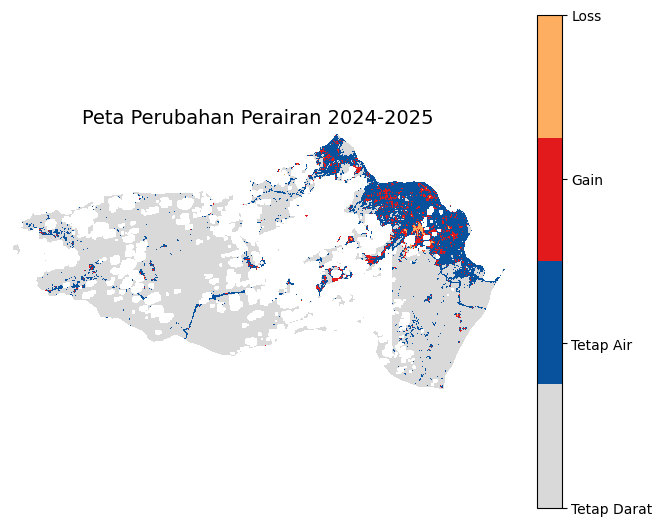

In [65]:
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["#d9d9d9", "#08519c", "#e31a1c", "#fdae61"])

plt.figure(figsize=(8, 8))
plt.imshow(np.where(change_map == 255, np.nan, change_map), cmap=cmap, vmin=0, vmax=3)
plt.title("Peta Perubahan Perairan 2024-2025", fontsize=14)
plt.axis("off")
cbar = plt.colorbar(ticks=[0, 1, 2, 3], shrink=0.8)
cbar.ax.set_yticklabels(["Tetap Darat", "Tetap Air", "Gain", "Loss"])
plt.show()

## 7. Export ke GeoJSON untuk WebGIS
Konversi raster klasifikasi & change map jadi vektor (polygon), sesuai struktur folder `04_GeoJSON_WebGIS/` tim.

In [66]:
from rasterio.features import shapes
import geopandas as gpd

def raster_ke_geojson(raster_path, output_path, value_filter=None):
    with rasterio.open(raster_path) as src:
        image = src.read(1)
        transform = src.transform
        crs = src.crs
    geoms = [{"properties": {"value": v}, "geometry": s} for s, v in shapes(image, transform=transform) if (value_filter is None or v in value_filter) and v != 255]
    if geoms:
        gpd.GeoDataFrame.from_features(geoms, crs=crs).to_file(output_path, driver="GeoJSON")
        print(f"Tersimpan: {output_path} ({len(geoms)} fitur)")

raster_ke_geojson("03_Hasil_Klasifikasi/klasifikasi_air_2024.tif", "04_GeoJSON_WebGIS/target_air_2024.geojson", value_filter=[1])
raster_ke_geojson("03_Hasil_Klasifikasi/klasifikasi_air_2025.tif", "04_GeoJSON_WebGIS/target_air_2025.geojson", value_filter=[1])
raster_ke_geojson("03_Hasil_Klasifikasi/change_map_air.tif", "04_GeoJSON_WebGIS/gain_air.geojson", value_filter=[2])
raster_ke_geojson("03_Hasil_Klasifikasi/change_map_air.tif", "04_GeoJSON_WebGIS/loss_air.geojson", value_filter=[3])

print("\nSEMUA PROSES SELESAI!")

Tersimpan: 04_GeoJSON_WebGIS/target_air_2024.geojson (138386 fitur)
Tersimpan: 04_GeoJSON_WebGIS/target_air_2025.geojson (164985 fitur)
Tersimpan: 04_GeoJSON_WebGIS/gain_air.geojson (142279 fitur)
Tersimpan: 04_GeoJSON_WebGIS/loss_air.geojson (182742 fitur)

SEMUA PROSES SELESAI!


## Selesai
Checklist Anggota 3:
- [x] Ground truth Perairan (300 titik per tahun)
- [x] Split 70:30, `random_state=42`
- [x] Random Forest 100 trees (per tahun)
- [x] Metrik APRF → `03_Evaluasi/metrik_aprf_air.txt`
- [x] Klasifikasi 2024 & 2025 → `03_Hasil_Klasifikasi/`
- [x] Change map (gain/loss) → `03_Hasil_Klasifikasi/change_map_air.tif`
- [x] GeoJSON untuk WebGIS → `04_GeoJSON_WebGIS/`

